In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/custom.css
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__results__.html
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__notebook__.ipynb
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/__output__.json
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/custom.css
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl
/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl


In [3]:
import joblib

X_train, X_test, y_train, y_test = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/splits/train_test.pkl"
)

le = joblib.load(
    "/kaggle/input/notebooks/hafsaferdousi5/01-data-preprocessing/outputs/models/label_encoder.pkl"
)

print(X_train.shape)
print(X_test.shape)

(5055991, 77)
(1263998, 77)


# LGBMClassifier

In [4]:
from lightgbm import LGBMClassifier

In [5]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.525109 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13757
[LightGBM] [Info] Number of data points in the train set: 5055991, number of used features: 69
[LightGBM] [Info] Start training from score -0.235451
[LightGBM] [Info] Start training from score -3.777951
[LightGBM] [Info] Start training from score -9.344775
[LightGBM] [Info] Start training from score -10.226598
[LightGBM] [Info] Start training from score -3.458865
[LightGBM] [Info] Start training from score -8.203351
[LightGBM] [Info] Start training from score -2.396470
[LightGBM] [Info] Start training from score -5.028041
[LightGBM] [Info] Start training from score -3.773369
[LightGBM] [Info] Start training from score -11.651895
[LightGBM] [Info] Start training from score -6.458181
[LightGBM] [Info] Start training from score -11.

LGBMClassifier(learning_rate=0.05, n_estimators=300, n_jobs=-1, random_state=42)

In [6]:
y_pred = lgbm.predict(X_test)
y_prob = lgbm.predict_proba(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [7]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
mcc = matthews_corrcoef(y_test, y_pred)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

auc = roc_auc_score(
    y_test_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"MCC      : {mcc:.4f}")
print(f"AUC      : {auc:.4f}")

Accuracy : 0.8684
Precision: 0.9188
Recall   : 0.8684
F1-score : 0.8814
MCC      : 0.6703
AUC      : 0.8908


In [8]:
attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=attack_names,
    zero_division=0
))

                          precision    recall  f1-score   support

                  Benign       0.97      0.93      0.95    998829
                     Bot       0.97      0.94      0.96     28907
        Brute Force -Web       0.00      0.00      0.00       111
        Brute Force -XSS       0.00      0.00      0.00        45
        DDOS attack-HOIC       0.29      0.99      0.45     39772
    DDoS attack-LOIC-UDP       0.00      0.00      0.00       346
  DDoS attacks-LOIC-HTTP       0.94      0.67      0.78    115073
   DoS attacks-GoldenEye       0.10      0.26      0.15      8281
        DoS attacks-Hulk       0.82      0.49      0.62     29040
DoS attacks-SlowHTTPTest       0.00      0.00      0.00        11
   DoS attacks-Slowloris       0.00      0.00      0.00      1982
          FTP-BruteForce       0.00      0.00      0.00        10
            Infiltration       0.05      0.03      0.04     22764
           SQL Injection       0.00      0.00      0.00        17
         

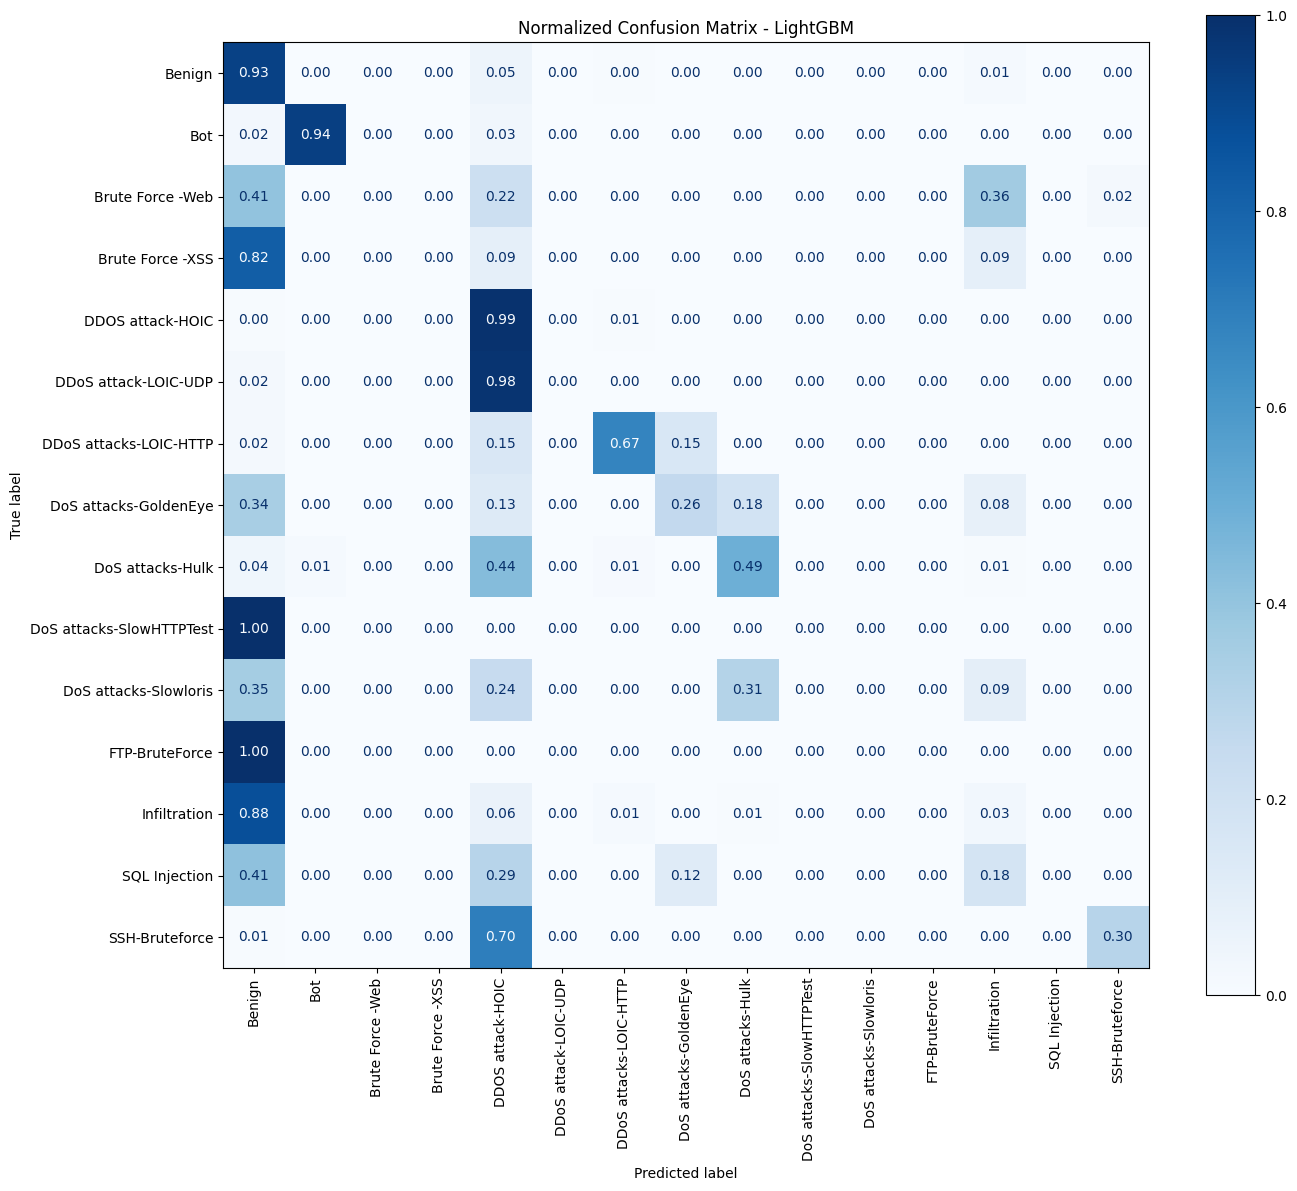

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title("Normalized Confusion Matrix - LightGBM")
plt.tight_layout()
plt.show()

In [10]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=40,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.577966 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13757
[LightGBM] [Info] Number of data points in the train set: 5055991, number of used features: 69
[LightGBM] [Info] Start training from score -0.235451
[LightGBM] [Info] Start training from score -3.777951
[LightGBM] [Info] Start training from score -9.344775
[LightGBM] [Info] Start training from score -10.226598
[LightGBM] [Info] Start training from score -3.458865
[LightGBM] [Info] Start training from score -8.203351
[LightGBM] [Info] Start training from score -2.396470
[LightGBM] [Info] Start training from score -5.028041
[LightGBM] [Info] Start training from score -3.773369
[LightGBM] [Info] Start training from score -11.651895
[LightGBM] [Info] Start training from score -6.458181
[LightGBM] [Info] Start training from score -11.

LGBMClassifier(learning_rate=0.05, n_estimators=300, n_jobs=-1, num_leaves=40,
               random_state=42)

In [11]:
y_pred = lgbm.predict(X_test)
y_prob = lgbm.predict_proba(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
mcc = matthews_corrcoef(y_test, y_pred)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

auc = roc_auc_score(
     y_test_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"MCC      : {mcc:.4f}")
print(f"AUC      : {auc:.4f}")

Accuracy : 0.8136
Precision: 0.8228
Recall   : 0.8136
F1-score : 0.7969
MCC      : 0.4307
AUC      : 0.7018


In [13]:
attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]

from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=attack_names,
    zero_division=0
))

                          precision    recall  f1-score   support

                  Benign       0.87      0.94      0.91    998829
                     Bot       0.73      0.84      0.78     28907
        Brute Force -Web       0.00      0.00      0.00       111
        Brute Force -XSS       0.00      0.00      0.00        45
        DDOS attack-HOIC       0.78      0.82      0.80     39772
    DDoS attack-LOIC-UDP       0.00      0.00      0.00       346
  DDoS attacks-LOIC-HTTP       0.99      0.26      0.41    115073
   DoS attacks-GoldenEye       0.09      0.01      0.02      8281
        DoS attacks-Hulk       0.00      0.00      0.00     29040
DoS attacks-SlowHTTPTest       0.00      0.00      0.00        11
   DoS attacks-Slowloris       0.00      0.00      0.00      1982
          FTP-BruteForce       0.00      0.00      0.00        10
            Infiltration       0.03      0.01      0.02     22764
           SQL Injection       0.00      0.00      0.00        17
         

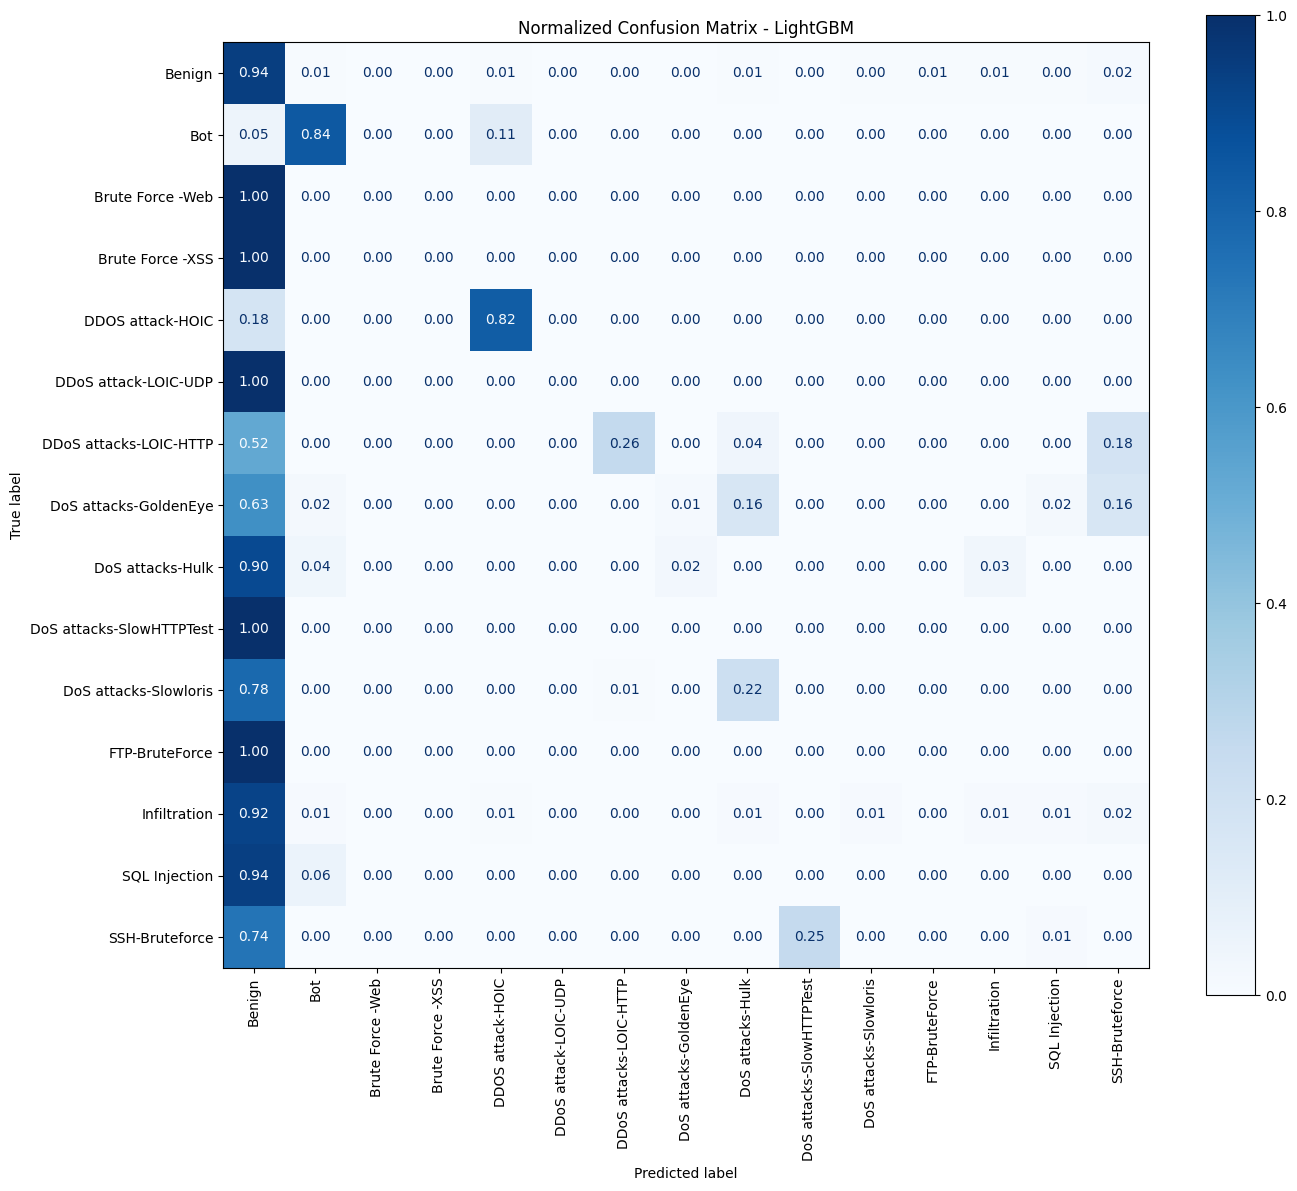

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title("Normalized Confusion Matrix - LightGBM")
plt.tight_layout()
plt.show()



In [15]:
import os

os.makedirs("outputs/models", exist_ok=True)
os.makedirs("outputs/results", exist_ok=True)

In [16]:
lgbm31 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)

lgbm31.fit(X_train, y_train)

y_pred31 = lgbm31.predict(X_test)
y_prob31 = lgbm31.predict_proba(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.466251 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13757
[LightGBM] [Info] Number of data points in the train set: 5055991, number of used features: 69
[LightGBM] [Info] Start training from score -0.235451
[LightGBM] [Info] Start training from score -3.777951
[LightGBM] [Info] Start training from score -9.344775
[LightGBM] [Info] Start training from score -10.226598
[LightGBM] [Info] Start training from score -3.458865
[LightGBM] [Info] Start training from score -8.203351
[LightGBM] [Info] Start training from score -2.396470
[LightGBM] [Info] Start training from score -5.028041
[LightGBM] [Info] Start training from score -3.773369
[LightGBM] [Info] Start training from score -11.651895
[LightGBM] [Info] Start training from score -6.458181
[LightGBM] [Info] Start training from score -11.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import numpy as np

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
mcc = matthews_corrcoef(y_test, y_pred)

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

auc = roc_auc_score(
    y_test_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"MCC      : {mcc:.4f}")
print(f"AUC      : {auc:.4f}")

Accuracy : 0.8136
Precision: 0.8228
Recall   : 0.8136
F1-score : 0.7969
MCC      : 0.4307
AUC      : 0.7018


In [18]:
attack_names = [
    "Benign",
    "Bot",
    "Brute Force -Web",
    "Brute Force -XSS",
    "DDOS attack-HOIC",
    "DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP",
    "DoS attacks-GoldenEye",
    "DoS attacks-Hulk",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris",
    "FTP-BruteForce",
    "Infiltration",
    "SQL Injection",
    "SSH-Bruteforce"
]

from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=attack_names,
    zero_division=0
))

                          precision    recall  f1-score   support

                  Benign       0.87      0.94      0.91    998829
                     Bot       0.73      0.84      0.78     28907
        Brute Force -Web       0.00      0.00      0.00       111
        Brute Force -XSS       0.00      0.00      0.00        45
        DDOS attack-HOIC       0.78      0.82      0.80     39772
    DDoS attack-LOIC-UDP       0.00      0.00      0.00       346
  DDoS attacks-LOIC-HTTP       0.99      0.26      0.41    115073
   DoS attacks-GoldenEye       0.09      0.01      0.02      8281
        DoS attacks-Hulk       0.00      0.00      0.00     29040
DoS attacks-SlowHTTPTest       0.00      0.00      0.00        11
   DoS attacks-Slowloris       0.00      0.00      0.00      1982
          FTP-BruteForce       0.00      0.00      0.00        10
            Infiltration       0.03      0.01      0.02     22764
           SQL Injection       0.00      0.00      0.00        17
         

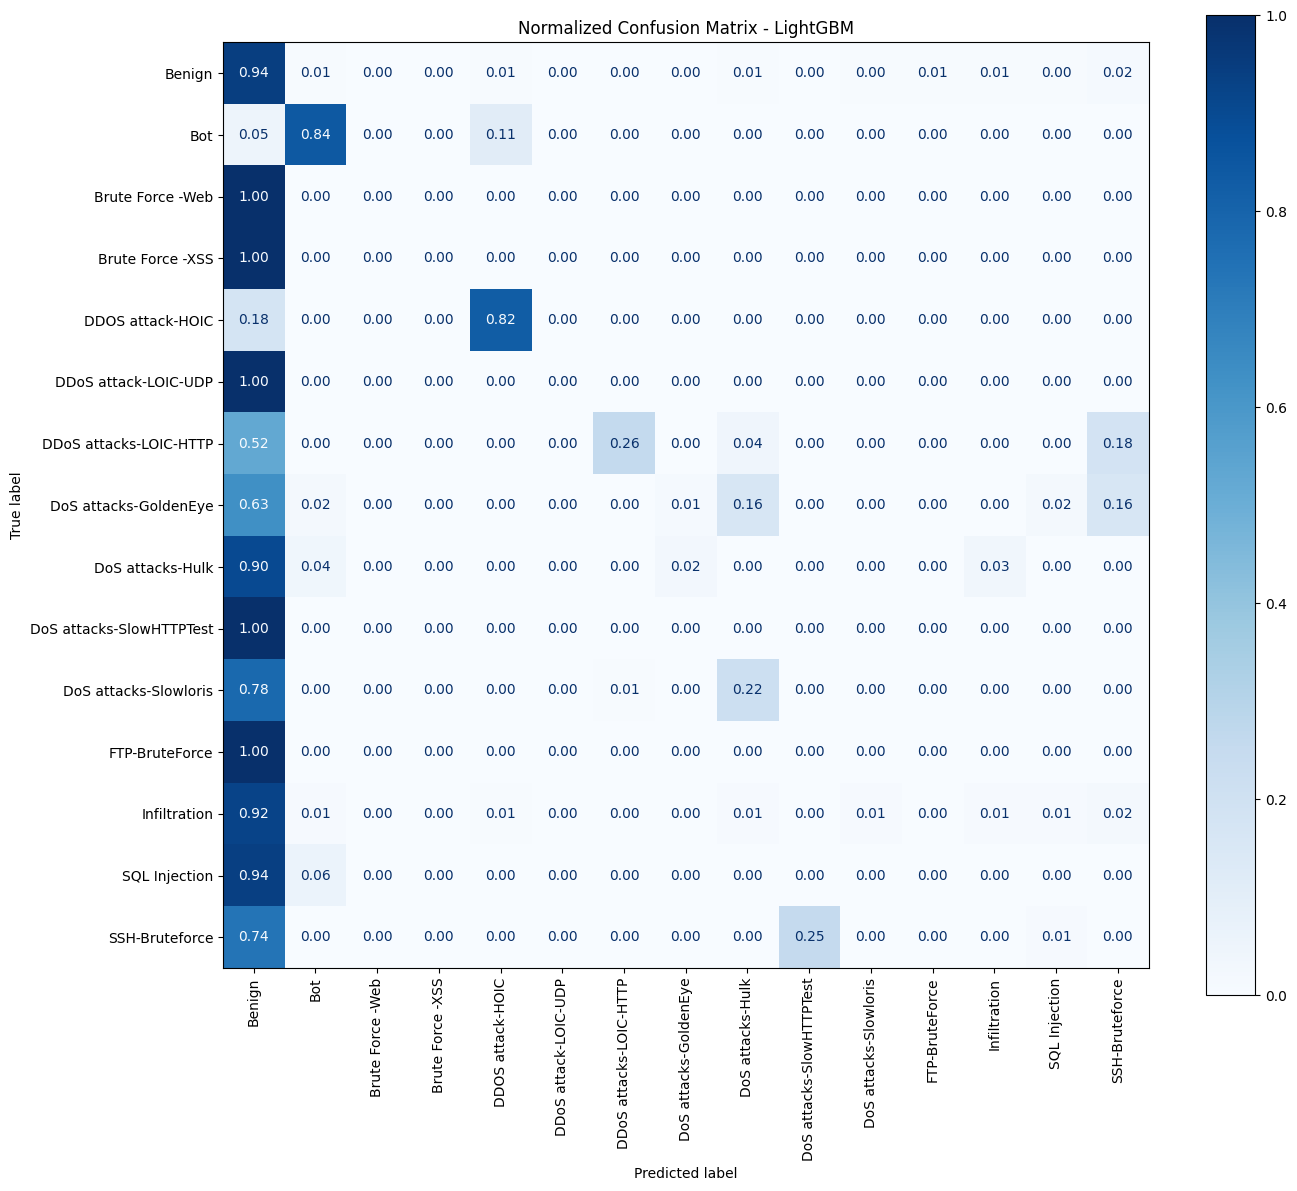

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title("Normalized Confusion Matrix - LightGBM")
plt.tight_layout()
plt.show()

In [20]:
import os
import joblib

os.makedirs("outputs/models", exist_ok=True)

joblib.dump(
    lgbm,
    "outputs/models/lightgbm_leaves31.pkl"
)

print("LightGBM (num_leaves=31) model saved!")

LightGBM (num_leaves=31) model saved!


In [21]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Model": ["LightGBM"],
    "num_leaves": [31],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1": [f1],
    "MCC": [mcc],
    "AUC": [auc]
})

metrics_df.to_csv(
    "outputs/results/lightgbm_leaves31_metrics.csv",
    index=False
)

print("Metrics saved!")

Metrics saved!


In [22]:
from sklearn.metrics import classification_report

attack_names = [
    "Benign","Bot","Brute Force -Web","Brute Force -XSS",
    "DDOS attack-HOIC","DDoS attack-LOIC-UDP",
    "DDoS attacks-LOIC-HTTP","DoS attacks-GoldenEye",
    "DoS attacks-Hulk","DoS attacks-SlowHTTPTest",
    "DoS attacks-Slowloris","FTP-BruteForce",
    "Infiltration","SQL Injection","SSH-Bruteforce"
]

report = classification_report(
    y_test,
    y_pred,
    labels=range(15),
    target_names=attack_names,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report).transpose().to_csv(
    "outputs/results/lightgbm_leaves31_classification_report.csv"
)

print("Classification Report saved!")

Classification Report saved!


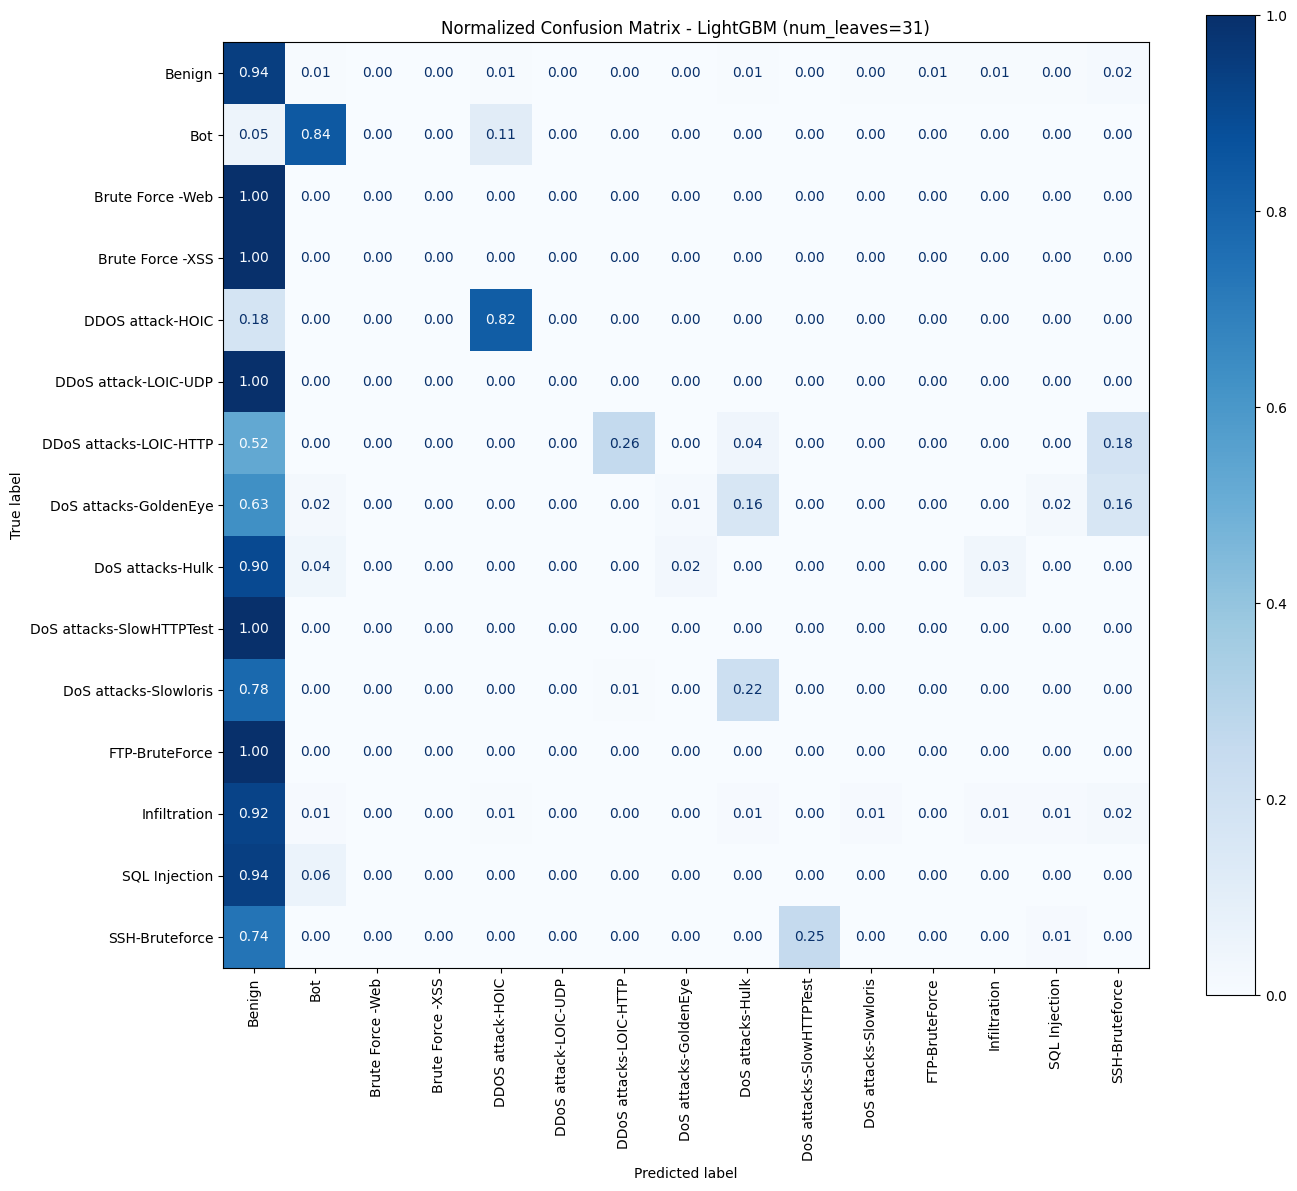

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14,12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=range(15),
    display_labels=attack_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title("Normalized Confusion Matrix - LightGBM (num_leaves=31)")
plt.tight_layout()

plt.savefig(
    "outputs/results/lightgbm_leaves31_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
import os

for root, dirs, files in os.walk("outputs"):
    for file in files:
        print(os.path.join(root, file))

outputs/results/lightgbm_leaves31_confusion_matrix.png
outputs/results/lightgbm_leaves31_metrics.csv
outputs/results/lightgbm_leaves31_classification_report.csv
outputs/models/lightgbm_leaves31.pkl
